<!-- KERNEL_BANNER -->
> **Use kernel: `mrigi_tor190_v8`**
>
> Set the notebook kernel to *Python (mrigi_tor190_v8)* before running.

# LLM-as-Judge for Mrigi 23j: Open-Ended Generation Quality — DUAL JUDGE (GPT-4.1 + GPT-4o)

Sister notebook to **30a**, but grading the **open-ended** answers produced by 23j (+ 23k merge) with **TWO judges** so we can compare their scores.

**Four judge tasks × 2 judges** (each scored 1–10 with reasoning):

1. **Correctness** — does the model's free-text answer match the gold answer?
2. **Completeness** — does it address the full question?
3. **Context Relevance** — how relevant was the retrieved context (skipped for `no_context`)
4. **Faithfulness** — does the answer avoid hallucinations / stay grounded in the context or well-known facts?

Judges compared: `gpt-4.1` and `gpt-4o`. Per-question, per-judge scores are stored under a `judges` sub-dict so 30c can compute agreement, correlation, and per-judge win/loss lists.

Input: `results_23j_checkpoint.json` (merged 14-model file after 23k recovery).

**Per-model resume:** on start, the notebook auto-discovers the newest `judge_results_23j_dual_final_*.json` in the current directory. Any model already present in that file is reused verbatim (including `-1` records); only models missing from the prior file (or new in the 23j checkpoint) get fresh OpenAI calls. Set `PRIOR_JUDGE_FILE = ''` in the resume cell to force a full re-judge.

In [1]:
# Core imports
import os
import json
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from openai import OpenAI
import httpx

# Load environment variables
with open('/home/jupyter/Mrigi/env.sh') as f:
    for line in f:
        line = line.strip()
        if line.startswith('export ') and '=' in line:
            key, val = line[len('export '):].split('=', 1)
            os.environ[key] = val.strip('"').strip("'")

openai_key = os.environ.get("OPENAI_API_TOKEN")
if not openai_key:
    raise ValueError("OPENAI_API_TOKEN not found in /home/jupyter/Mrigi/env.sh")

client = OpenAI(api_key=openai_key, http_client=httpx.Client())
print(f"✓ OpenAI client initialized")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ OpenAI client initialized
✓ Timestamp: 2026-08-02 18:47:36


## Load 23j results

In [2]:
# Load the 23j checkpoint (or a specific complete file)
RESULTS_FILE = 'results_23j_checkpoint.json'

if not os.path.exists(RESULTS_FILE):
    candidates = sorted(glob.glob('results_23j_*.json'))
    print("Available 23j result files:")
    for c in candidates:
        print(f"  {c}  ({os.path.getsize(c)/(1024*1024):.1f} MB)")
    raise FileNotFoundError(
        f"{RESULTS_FILE!r} not found. Run 23j first, or point RESULTS_FILE at one of the above."
    )

with open(RESULTS_FILE) as f:
    all_results = json.load(f)

print(f"Loaded: {RESULTS_FILE} ({os.path.getsize(RESULTS_FILE)/(1024*1024):.2f} MB)")
print(f"Models in file: {len(all_results)}")
for model_name, model_data in all_results.items():
    if not isinstance(model_data, dict):
        print(f"  {model_name}: (unexpected shape: {type(model_data).__name__})")
        continue
    if 'load_error' in model_data:
        print(f"  {model_name}: LOAD ERROR ({str(model_data['load_error'])[:60]})")
        continue
    methods = [m for m in model_data.keys() if m in ('no_context', 'mmr')]
    parts = []
    for m in methods:
        r = model_data.get(m, {})
        n = len(r.get('detailed_results', []))
        parts.append(f"{m}={n}q")
    print(f"  {model_name:30s}  " + "  ".join(parts))

Loaded: results_23j_checkpoint.json (64.38 MB)
Models in file: 14
  Llama-3-8B-Instruct             no_context=100q  mmr=100q
  DAPT_LR1e5                      no_context=100q  mmr=100q
  DAPT_LR1e5_COT                  no_context=100q  mmr=100q
  synv2V2_step80                  no_context=100q  mmr=100q
  synv2V2_step80_COT              no_context=100q  mmr=100q
  synv2V2_final                   no_context=100q  mmr=100q
  synv2V2_final_COT               no_context=100q  mmr=100q
  synv2_base_step80               no_context=100q  mmr=100q
  synv2_base_step80_COT           no_context=100q  mmr=100q
  synv2_base_final                no_context=100q  mmr=100q
  synv2_base_final_COT            no_context=100q  mmr=100q
  fullpaper_120M_LR1e5            no_context=100q  mmr=100q
  fullpaper_120M_COT              no_context=100q  mmr=100q
  base_llama_COT                  no_context=100q  mmr=100q


In [3]:
# Determine which models are judgeable: skip load_errors, require both methods present with detailed_results
MODELS_TO_JUDGE = []
SKIPPED = []
for model_name, model_data in all_results.items():
    if not isinstance(model_data, dict) or 'load_error' in model_data:
        SKIPPED.append((model_name, 'load_error or unexpected shape'))
        continue
    has_nc = 'detailed_results' in model_data.get('no_context', {}) and len(model_data['no_context']['detailed_results']) > 0
    has_mmr = 'detailed_results' in model_data.get('mmr', {}) and len(model_data['mmr']['detailed_results']) > 0
    if has_nc and has_mmr:
        MODELS_TO_JUDGE.append(model_name)
    else:
        SKIPPED.append((model_name, f"incomplete: no_context={has_nc}, mmr={has_mmr}"))

METHODS = ['no_context', 'mmr']
print(f"✓ Will judge {len(MODELS_TO_JUDGE)} models × {len(METHODS)} methods")
for m in MODELS_TO_JUDGE:
    print(f"    ✓ {m}")
if SKIPPED:
    print(f"\n⚠ Skipping {len(SKIPPED)} models:")
    for name, why in SKIPPED:
        print(f"    ✗ {name}  ({why})")

✓ Will judge 14 models × 2 methods
    ✓ Llama-3-8B-Instruct
    ✓ DAPT_LR1e5
    ✓ DAPT_LR1e5_COT
    ✓ synv2V2_step80
    ✓ synv2V2_step80_COT
    ✓ synv2V2_final
    ✓ synv2V2_final_COT
    ✓ synv2_base_step80
    ✓ synv2_base_step80_COT
    ✓ synv2_base_final
    ✓ synv2_base_final_COT
    ✓ fullpaper_120M_LR1e5
    ✓ fullpaper_120M_COT
    ✓ base_llama_COT


## Resume: skip models already judged in a prior run

Per-model granularity: if a model appears anywhere in the last saved `judge_results_23j_dual_final_*.json` file (schema `dual-judge-v1`), it is treated as done and skipped — no re-judging, no OpenAI calls for those. `-1` records (judge errors or model ERROR/INVALID upstream) are preserved from the prior file as-is. Only models that are missing from the prior file (or if no prior file exists) are freshly judged. The output is a fresh timestamped file that contains everything: reused prior entries + newly judged entries.

In [4]:
# ---- GPT-5.2 (Table 1 row 1) ----------------------------------------------
# GPT-5.2 is an API model with no entry in results_23j_checkpoint.json, so its
# answers are generated in the next cell before judging. Paper reports no-context
# only, so it never gets an mmr condition.
GPT52_LABEL = 'GPT-5.2'
GPT52_MODEL_ID = 'gpt-5.2'   # pin to 'gpt-5.2-2025-12-11' for exact reproducibility

# Per-model method overrides. Anything absent uses the default METHODS.
MODEL_METHODS = {GPT52_LABEL: ['no_context']}

# ============================================================
# Resume (merge across ALL prior judge files) + explicit model selection
# ============================================================
# Judge scores for different models are scattered across several prior runs
# (earlier runs died part-way when the OpenAI credit balance ran out). So instead
# of trusting a single "newest" file, scan every prior judge file and keep, for
# each model, the version with the highest fraction of real (non -1) scores.

# ONLY_JUDGE_MODELS: if non-empty, judge EXACTLY these and nothing else.
# These are the 3 CoT variants missing from the CoT-vs-base plot; every other
# model already has usable scores in one of the prior files.
ONLY_JUDGE_MODELS = [
    'base_llama_COT',        # Table 1 row 3
    'fullpaper_120M_COT',    # Table 1 row 10
    # GPT52_LABEL,           # Table 1 row 1 - SKIPPED for now. Uncomment to generate
                             # (no_context only) and judge GPT-5.2; the generation cell
                             # below no-ops while this stays commented out.
]
# Set ONLY_JUDGE_MODELS = [] for normal behaviour (judge whatever the merged
# prior results don't already cover).

# Files to harvest prior scores from. None -> all dual-judge final+intermediate files.
PRIOR_JUDGE_GLOBS = None   # e.g. ['judge_results_23j_dual_final_*.json'] to restrict
MIN_VALID_FRACTION = 0.5   # below this, a model's prior scores are treated as unusable


def _valid_fraction(mdata):
    """Fraction of (question x judge) slots carrying a real correctness score."""
    total = valid = 0
    for mt in METHODS:
        for r in (mdata.get(mt) or []):
            if not r:
                continue
            for _jm, entry in r.get('judges', {}).items():
                total += 1
                if entry.get('correctness_score', -1) > 0:
                    valid += 1
    return (valid / total) if total else 0.0


globs = PRIOR_JUDGE_GLOBS or [
    'judge_results_23j_dual_final_*.json',
    'judge_results_23j_dual_intermediate_*.json',
]
prior_files = sorted({f for g in globs for f in glob.glob(g)}, key=os.path.getmtime)

# model -> (valid_fraction, source_file, data)
_best = {}
for fpath in prior_files:
    with open(fpath) as fh:
        payload = json.load(fh)
    results = payload.get('results', payload)   # finals are wrapped, intermediates are bare
    for m, mdata in results.items():
        if not isinstance(mdata, dict):
            continue
        frac = _valid_fraction(mdata)
        if m not in _best or frac > _best[m][0]:
            _best[m] = (frac, os.path.basename(fpath), mdata)

judge_results_prior = {}
REUSED_MODELS = []
DISCARDED_PRIOR = []
for m, (frac, fname, mdata) in _best.items():
    if frac >= MIN_VALID_FRACTION:
        judge_results_prior[m] = mdata
        REUSED_MODELS.append((m, frac, fname))
    else:
        DISCARDED_PRIOR.append((m, frac, fname))

print(f'Scanned {len(prior_files)} prior judge file(s):')
for f in prior_files:
    print(f'    {os.path.basename(f)}  ({os.path.getsize(f)/(1024*1024):.1f} MB)')

print(f'\nReusable models: {len(REUSED_MODELS)}')
for m, frac, fname in sorted(REUSED_MODELS):
    print(f'    reuse  {m:<24} {frac:>5.0%} valid   from {fname[-18:-5]}')
if DISCARDED_PRIOR:
    print(f'\nUnusable prior entries (below {MIN_VALID_FRACTION:.0%} valid): {len(DISCARDED_PRIOR)}')
    for m, frac, fname in sorted(DISCARDED_PRIOR):
        print(f'    drop   {m:<24} {frac:>5.0%} valid   (best was {fname[-18:-5]})')

# ---- decide what to judge -------------------------------------------------
MODELS_IN_SOURCE = list(MODELS_TO_JUDGE)

if ONLY_JUDGE_MODELS:
    # GPT-5.2 is injected by the generation cell below, so it is legitimately
    # absent from the 23j checkpoint at this point.
    absent = [m for m in ONLY_JUDGE_MODELS
              if m not in MODELS_IN_SOURCE and m != GPT52_LABEL]
    if absent:
        raise ValueError(f'ONLY_JUDGE_MODELS not present in {RESULTS_FILE}: {absent}')
    MODELS_TO_JUDGE = list(ONLY_JUDGE_MODELS)
    # never reuse a model we were explicitly told to (re-)judge
    for m in MODELS_TO_JUDGE:
        judge_results_prior.pop(m, None)
    REUSED_MODELS = [t for t in REUSED_MODELS if t[0] not in MODELS_TO_JUDGE]
    mode = f'explicit list ({len(MODELS_TO_JUDGE)} models)'
else:
    MODELS_TO_JUDGE = [m for m in MODELS_TO_JUDGE if m not in judge_results_prior]
    mode = 'auto (source minus merged prior)'

print(f'\nSelection mode: {mode}')
print(f'  models in source file: {len(MODELS_IN_SOURCE)}')
print(f'  reused from prior:     {len(REUSED_MODELS)}')
print(f'  TO JUDGE NOW:          {len(MODELS_TO_JUDGE)}')
for m in MODELS_TO_JUDGE:
    print(f'    judge  {m}')

_n_judges = len(globals().get('JUDGE_MODELS', ['gpt-4.1', 'gpt-4o']))
_n_q = 100  # questions per model/method in this benchmark
# task-slots per method: mmr = 4 tasks, no_context = 3 (relevance skipped)
_SLOTS = {'mmr': 4, 'no_context': 3}
_calls = sum(_SLOTS[mt] * _n_q * _n_judges
             for m in MODELS_TO_JUDGE
             for mt in MODEL_METHODS.get(m, METHODS))
print(f'\n  approx OpenAI calls this run: {_calls:,}  (judging only)')
for m in MODELS_TO_JUDGE:
    print(f'      {m:<24} methods={MODEL_METHODS.get(m, METHODS)}')
print(f'  final file will contain:      {len(REUSED_MODELS) + len(MODELS_TO_JUDGE)} models')
if not MODELS_TO_JUDGE:
    print('\n  nothing to judge — main loop will be skipped')

Scanned 4 prior judge file(s):
    judge_results_23j_dual_intermediate_20260721_165400.json  (15.8 MB)
    judge_results_23j_dual_final_20260721_165400.json  (15.8 MB)
    judge_results_23j_dual_intermediate_20260729_141318.json  (29.8 MB)
    judge_results_23j_dual_intermediate_20260731_145301.json  (18.0 MB)

Reusable models: 11
    reuse  DAPT_LR1e5                100% valid   from 260721_165400
    reuse  DAPT_LR1e5_COT            100% valid   from 260729_141318
    reuse  Llama-3-8B-Instruct       100% valid   from 260721_165400
    reuse  fullpaper_120M_LR1e5      100% valid   from 260721_165400
    reuse  synv2V2_final             100% valid   from 260721_165400
    reuse  synv2V2_final_COT         100% valid   from 260729_141318
    reuse  synv2V2_step80            100% valid   from 260721_165400
    reuse  synv2V2_step80_COT        100% valid   from 260729_141318
    reuse  synv2_base_final          100% valid   from 260721_165400
    reuse  synv2_base_step80         100% vali

## Generate GPT-5.2 answers (no-context only)

GPT-5.2 has no entry in the 23j generation checkpoint, so its answers are produced here using the **same no-context prompt as 23j** (verbatim), against the same 100 questions and the same gold answers. Results are cached to `results_gpt52_nocontext_<ts>.json`, so re-running this cell reuses them instead of paying for generation twice.

In [5]:
# Verbatim copy of 23j's NO_CONTEXT_OPEN_ENDED_PROMPT so GPT-5.2 is prompted
# identically to every open-weight model in the benchmark.
NO_CONTEXT_OPEN_ENDED_PROMPT = """You are an expert on zeolite synthesis, chemistry, and catalysis. Answer the following question using your own knowledge. Give a clear, focused answer in 3\u20135 sentences (or fewer if the question is simple). Do not invent citations. Do not restate the question.

Question: {question}

Answer:"""

GPT52_MAX_TOKENS = 400      # matches 23j's max_new_tokens=400
GPT52_CACHE_GLOB = 'results_gpt52_nocontext_*.json'
GPT52_WORKERS = 8

if GPT52_LABEL in MODELS_TO_JUDGE:
    # --- reuse a cached generation if one exists -----------------------------
    _cached = sorted(glob.glob(GPT52_CACHE_GLOB), key=os.path.getmtime)
    gpt52_records = None
    if _cached:
        with open(_cached[-1]) as fh:
            _c = json.load(fh)
        _recs = _c.get('detailed_results', [])
        _ok = sum(1 for r in _recs if r.get('model_answer') not in ('ERROR', 'INVALID', '', None))
        if _ok >= 0.9 * len(_recs) and _recs:
            gpt52_records = _recs
            print(f'Reusing cached GPT-5.2 generation: {_cached[-1]}  ({_ok}/{len(_recs)} valid)')
        else:
            print(f'Cached GPT-5.2 file {_cached[-1]} only {_ok}/{len(_recs)} valid - regenerating')

    if gpt52_records is None:
        # Take the exact question set + gold answers from an already-judged model so
        # GPT-5.2 is scored on identical inputs.
        _template_model = next(m for m in all_results
                               if 'load_error' not in all_results.get(m, {})
                               and all_results[m].get('no_context', {}).get('detailed_results'))
        _template = all_results[_template_model]['no_context']['detailed_results']
        print(f'Question set taken from: {_template_model}  ({len(_template)} questions)')

        def _gpt52_one(idx, rec):
            prompt = NO_CONTEXT_OPEN_ENDED_PROMPT.format(question=rec['query'])
            kwargs = dict(model=GPT52_MODEL_ID,
                          messages=[{'role': 'user', 'content': prompt}],
                          max_completion_tokens=GPT52_MAX_TOKENS)
            for attempt in range(3):
                try:
                    resp = client.chat.completions.create(**kwargs)
                    ans = (resp.choices[0].message.content or '').strip()
                    return idx, {
                        'query': rec['query'],
                        'model_answer': ans if ans else 'INVALID',
                        'correct_answer_text': rec.get('correct_answer_text', ''),
                        'correct_answer_letter': rec.get('correct_answer_letter', ''),
                        'full_response': ans,
                        'title': rec.get('title'),
                        'doi': rec.get('doi'),
                    }
                except Exception as e:
                    msg = str(e)
                    # some reasoning models reject non-default sampling params
                    if 'temperature' in msg and 'temperature' in kwargs:
                        kwargs.pop('temperature', None); continue
                    if 'max_completion_tokens' in msg or 'max_tokens' in msg:
                        kwargs.pop('max_completion_tokens', None)
                        kwargs['max_tokens'] = GPT52_MAX_TOKENS
                        continue
                    if attempt == 2:
                        return idx, {
                            'query': rec['query'], 'model_answer': 'ERROR',
                            'correct_answer_text': rec.get('correct_answer_text', ''),
                            'correct_answer_letter': rec.get('correct_answer_letter', ''),
                            'title': rec.get('title'), 'doi': rec.get('doi'),
                            'error': msg[:300],
                        }
                    time.sleep(5)

        gpt52_records = [None] * len(_template)
        with ThreadPoolExecutor(max_workers=GPT52_WORKERS) as ex:
            futs = [ex.submit(_gpt52_one, i, r) for i, r in enumerate(_template)]
            for fut in tqdm(as_completed(futs), total=len(futs),
                            desc=f'  generating {GPT52_LABEL} (no_context)'):
                i, rec = fut.result()
                gpt52_records[i] = rec

        _n_valid = sum(1 for r in gpt52_records
                       if r.get('model_answer') not in ('ERROR', 'INVALID'))
        _ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        _out = f'results_gpt52_nocontext_{_ts}.json'
        with open(_out, 'w') as fh:
            json.dump({
                'model': GPT52_LABEL, 'model_id': GPT52_MODEL_ID,
                'method': 'no_context', 'timestamp': _ts,
                'prompt': NO_CONTEXT_OPEN_ENDED_PROMPT,
                'max_tokens': GPT52_MAX_TOKENS,
                'n_valid': _n_valid, 'total': len(gpt52_records),
                'detailed_results': gpt52_records,
            }, fh, indent=2)
        print(f'\nSaved: {_out}   ({_n_valid}/{len(gpt52_records)} valid)')

    # --- inject into all_results so the judge loop treats it like any model ---
    all_results[GPT52_LABEL] = {
        'no_context': {
            'method': 'no_context',
            'n_valid': sum(1 for r in gpt52_records
                           if r.get('model_answer') not in ('ERROR', 'INVALID')),
            'total': len(gpt52_records),
            'detailed_results': gpt52_records,
        }
    }
    print(f'{GPT52_LABEL} ready for judging: {len(gpt52_records)} no_context answers')
    print(f'   sample: {gpt52_records[0]["model_answer"][:160]}...')
else:
    print(f'{GPT52_LABEL} not in MODELS_TO_JUDGE - skipping generation')

GPT-5.2 not in MODELS_TO_JUDGE - skipping generation


## Judge Prompts (Open-Ended) — shared by both judges

In [6]:
JUDGE_SYSTEM_PROMPT = """You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system 
focused on zeolite synthesis, catalysis, and environmental applications. 
You will evaluate the quality of retrieved contexts and open-ended generated responses 
against a reference (gold) answer.
Always respond in valid JSON format."""

# ------------------------------------------------------------------
# Task 1: Context Relevance (identical to 30a — context vs query, no answer needed)
# ------------------------------------------------------------------
CONTEXT_RELEVANCE_PROMPT = """Given the following query and retrieved context, rate how relevant the context is for answering the query.

**Scoring Rubric (1-10):**
- 1-2: Completely irrelevant — context has no connection to the query topic
- 3-4: Mostly irrelevant — context touches on the general domain but doesn't address the specific question
- 5-6: Partially relevant — context contains some useful information but misses key aspects
- 7-8: Mostly relevant — context addresses the main topic and provides useful information for answering
- 9-10: Highly relevant — context directly addresses the query with specific, useful information

**Query:**
{query}

**Retrieved Context:**
{context}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

# ------------------------------------------------------------------
# Task 2: Correctness — free-text answer vs gold answer
# ------------------------------------------------------------------
OPEN_ENDED_CORRECTNESS_PROMPT = """Given the following query, a reference (gold) answer, and a model's open-ended response, rate how correct the response is.

Judge on scientific substance, not wording. The response may phrase things differently, be more or less detailed, or add related information — that is fine as long as the core claim matches the reference and any additional claims are accurate.

**Scoring Rubric (1-10):**
- 1-2: Completely incorrect — asserts something that contradicts the reference answer
- 3-4: Mostly incorrect — misses the main point, but shows partial understanding of the topic
- 5-6: Partially correct — captures part of the reference answer but is missing or muddling the key idea
- 7-8: Mostly correct — captures the key idea of the reference answer, with minor gaps or imprecise phrasing
- 9-10: Fully correct — captures the reference answer's key idea clearly and accurately (extra correct detail is fine)

**Query:**
{query}

**Reference (Gold) Answer:**
{gold_answer}

**Model's Open-Ended Response:**
{response}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

# ------------------------------------------------------------------
# Task 3: Completeness — how fully the response addresses the question
# ------------------------------------------------------------------
OPEN_ENDED_COMPLETENESS_PROMPT = """Given the following query and a model's open-ended response, rate how completely the response addresses the question.

Judge how much of what the question is asking for is present — the main mechanism, the reason, or the required piece of reasoning. Do not penalize concise answers if they cover the essential point; do penalize hand-wavy or partial answers that skip the substantive part.

**Scoring Rubric (1-10):**
- 1-2: No meaningful response — empty, garbled, refuses, or completely off-topic
- 3-4: Minimal response — mentions the topic but does not really answer the question
- 5-6: Partial response — addresses part of the question but leaves the key aspect unexplained
- 7-8: Good response — addresses the question with a clear, relevant explanation of the main point
- 9-10: Excellent response — fully addresses the question with a thorough, well-reasoned explanation

**Query:**
{query}

**Model's Open-Ended Response:**
{response}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

# ------------------------------------------------------------------
# Task 4: Faithfulness — does the answer avoid hallucinated / unsupported claims?
# ------------------------------------------------------------------
OPEN_ENDED_FAITHFULNESS_PROMPT = """Given the following query, retrieved context, and a model's open-ended response, rate how faithful the response is — i.e., how well its claims are grounded in the retrieved context or in uncontested, well-known zeolite science, and how free it is of hallucinated / invented details.

Do NOT reward or penalize based on whether the response is correct (that is scored separately). Score only whether the response invents specific facts, cites nonexistent papers/values, or makes claims that neither the context nor common knowledge in zeolite science would support.

**Scoring Rubric (1-10):**
- 1-2: Response is dominated by hallucinated / fabricated claims (invented numbers, nonexistent references, made-up mechanisms) not supported by context or standard knowledge
- 3-4: Response has multiple unsupported / suspicious claims mixed with grounded ones
- 5-6: Response has a few unsupported or borderline claims but is largely grounded
- 7-8: Response is well-grounded, with at most one minor unsupported detail
- 9-10: Every substantive claim is either directly supported by the context or is uncontroversial zeolite-science common knowledge

If no context was provided (i.e., this is a no-context run), judge purely against uncontroversial zeolite-science common knowledge.

**Query:**
{query}

**Retrieved Context (may be empty):**
{context}

**Model's Open-Ended Response:**
{response}

Respond with ONLY a JSON object in this exact format:
{{"score": <integer 1-10>, "reasoning": "<one to two sentences explaining your score>"}}"""

print("✓ Judge prompts defined (4 tasks: relevance, correctness, completeness, faithfulness)")

✓ Judge prompts defined (4 tasks: relevance, correctness, completeness, faithfulness)


In [7]:
# ------------------------------------------------------------------
# Dual-judge configuration
# ------------------------------------------------------------------
JUDGE_MODELS = ['gpt-4.1', 'gpt-4o']  # both judges scored on the same prompt


def call_judge(judge_model, system_prompt, user_prompt, max_retries=3, retry_delay=5):
    """Call the given OpenAI judge model and parse a {'score': int, 'reasoning': str} JSON.
    Returns {'score': -1, 'reasoning': '<error>'} on failure."""
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=judge_model,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=0.1,
                max_tokens=200,
                response_format={"type": "json_object"},
            )
            content = response.choices[0].message.content.strip()
            result = json.loads(content)
            score = int(result.get('score', -1))
            if 1 <= score <= 10:
                return {'score': score, 'reasoning': result.get('reasoning', '')}
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
                continue
            return {'score': score, 'reasoning': f"Score out of range: {result}"}
        except json.JSONDecodeError as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
                continue
            return {'score': -1, 'reasoning': f"JSON parse error: {str(e)}"}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(retry_delay)
                continue
            return {'score': -1, 'reasoning': f"API error [{judge_model}]: {str(e)}"}
    return {'score': -1, 'reasoning': 'Max retries exceeded'}


def _score_one_task(judge_model, task, query, ctx_rel, ctx_faith, response_text, gold_answer, method_name):
    """Dispatch one task -> one judge call."""
    if task == 'relevance':
        if method_name == 'no_context' or not ctx_rel:
            return {'score': -1, 'reasoning': 'N/A — no context provided for this method'}
        return call_judge(judge_model, JUDGE_SYSTEM_PROMPT,
                          CONTEXT_RELEVANCE_PROMPT.format(query=query, context=ctx_rel))
    if task == 'correctness':
        return call_judge(judge_model, JUDGE_SYSTEM_PROMPT,
                          OPEN_ENDED_CORRECTNESS_PROMPT.format(
                              query=query, gold_answer=gold_answer, response=response_text))
    if task == 'completeness':
        return call_judge(judge_model, JUDGE_SYSTEM_PROMPT,
                          OPEN_ENDED_COMPLETENESS_PROMPT.format(query=query, response=response_text))
    if task == 'faithfulness':
        ctx_for_faith = ctx_faith if ctx_faith else 'No context — judge purely on standard zeolite-science common knowledge.'
        return call_judge(judge_model, JUDGE_SYSTEM_PROMPT,
                          OPEN_ENDED_FAITHFULNESS_PROMPT.format(
                              query=query, context=ctx_for_faith, response=response_text))
    raise ValueError(f"Unknown task: {task}")


TASKS_LIST = ['relevance', 'correctness', 'completeness', 'faithfulness']


def evaluate_single_question(question_result, method_name):
    """Run 4 tasks × 2 judges = up to 8 scoring calls on a single 23j/23k question result.

    Returns a nested dict:
        {
            'query': ..., 'model_answer': ..., 'gold_answer': ..., 'title': ..., 'doi': ...,
            'judges': {
                'gpt-4.1': {'relevance_score': X, 'relevance_reasoning': ..., ...},
                'gpt-4o':  {'relevance_score': Y, ...},
            }
        }
    Judges are called SEQUENTIALLY within a question so we don\'t explode the request rate;
    parallelism comes from the outer ThreadPoolExecutor across questions.
    """
    query = question_result.get('query', '')
    context = question_result.get('context', '') or ''
    model_answer = question_result.get('model_answer', '')
    gold_answer = question_result.get('correct_answer_text', '')
    full_response = question_result.get('full_response', '')

    response_text = model_answer if model_answer else full_response
    ctx_rel   = context[:3000] + '...' if len(context) > 3000 else context
    ctx_faith = context[:3000] + '...' if len(context) > 3000 else context

    per_judge = {}
    for jm in JUDGE_MODELS:
        entry = {}
        for task in TASKS_LIST:
            r = _score_one_task(jm, task, query, ctx_rel, ctx_faith, response_text, gold_answer, method_name)
            entry[f'{task}_score'] = r['score']
            entry[f'{task}_reasoning'] = r['reasoning']
        per_judge[jm] = entry

    return {
        'query': query,
        'model_answer': model_answer,
        'gold_answer': gold_answer,
        'title': question_result.get('title'),
        'doi': question_result.get('doi'),
        'judges': per_judge,
    }

print(f"✓ Dual-judge functions defined  (judges: {JUDGE_MODELS}, tasks: {TASKS_LIST})")

✓ Dual-judge functions defined  (judges: ['gpt-4.1', 'gpt-4o'], tasks: ['relevance', 'correctness', 'completeness', 'faithfulness'])


## Run the parallel judge evaluation

In [8]:
# Build evaluation plan and report scope (× 2 judges now)
eval_plan = []
for model in MODELS_TO_JUDGE:
    for method in MODEL_METHODS.get(model, METHODS):
        n = len(all_results[model][method]['detailed_results'])
        eval_plan.append({'model': model, 'method': method, 'n_questions': n})

total_questions = sum(p['n_questions'] for p in eval_plan)
# 4 tasks/q per judge, × 2 judges, minus (relevance × 2 judges) calls skipped for no_context
no_context_questions = sum(p['n_questions'] for p in eval_plan if p['method'] == 'no_context')
total_api_calls = total_questions * 4 * len(JUDGE_MODELS) - no_context_questions * len(JUDGE_MODELS)

print(f"Evaluation plan (dual-judge):")
print(f"  {len(MODELS_TO_JUDGE)} models × {len(METHODS)} methods = {len(eval_plan)} combinations")
print(f"  Total questions to judge: {total_questions}")
print(f"  Judges: {JUDGE_MODELS}")
print(f"  Estimated OpenAI calls:   {total_api_calls}  (4 tasks/q × {len(JUDGE_MODELS)} judges, minus relevance for no_context)")
print(f"\nBreakdown:")
for p in eval_plan:
    print(f"  {p['model']:35s}  {p['method']:<12s}  {p['n_questions']} questions")

Evaluation plan (dual-judge):
  2 models × 2 methods = 4 combinations
  Total questions to judge: 400
  Judges: ['gpt-4.1', 'gpt-4o']
  Estimated OpenAI calls:   2800  (4 tasks/q × 2 judges, minus relevance for no_context)

Breakdown:
  base_llama_COT                       no_context    100 questions
  base_llama_COT                       mmr           100 questions
  fullpaper_120M_COT                   no_context    100 questions
  fullpaper_120M_COT                   mmr           100 questions


In [9]:
MAX_WORKERS = 8
SKIPPED_ANSWERS = {'ERROR', 'INVALID'}


def _skipped_record(q_result):
    per_judge = {}
    for jm in JUDGE_MODELS:
        per_judge[jm] = {
            'relevance_score': -1,    'relevance_reasoning': 'Skipped — model returned ERROR/INVALID',
            'correctness_score': -1,  'correctness_reasoning': 'Skipped — model returned ERROR/INVALID',
            'completeness_score': -1, 'completeness_reasoning': 'Skipped — model returned ERROR/INVALID',
            'faithfulness_score': -1, 'faithfulness_reasoning': 'Skipped — model returned ERROR/INVALID',
        }
    return {
        'query': q_result.get('query', ''),
        'model_answer': q_result.get('model_answer', ''),
        'gold_answer': q_result.get('correct_answer_text', ''),
        'title': q_result.get('title'),
        'doi': q_result.get('doi'),
        'judges': per_judge,
    }


def _judge_one(idx, q_result, method):
    if q_result.get('model_answer') in SKIPPED_ANSWERS:
        return idx, _skipped_record(q_result)
    return idx, evaluate_single_question(q_result, method)


# Seed with prior-file entries so reused models survive to the final save.
judge_results = dict(judge_results_prior)  # {model: {method: [per-q dicts]}}
judge_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
intermediate_path = f'judge_results_23j_dual_intermediate_{judge_timestamp}.json'

start_time = time.time()
total_evaluated = 0

if not MODELS_TO_JUDGE:
    print('Nothing to judge — MODELS_TO_JUDGE is empty (all covered by prior file).')
    print('Skipping main loop; will still write a fresh timestamped file below.')

for model in MODELS_TO_JUDGE:
    judge_results[model] = {}
    print(f"\n{'='*80}")
    print(f"Model: {model}")
    print(f"{'='*80}")

    for method in MODEL_METHODS.get(model, METHODS):
        detailed = all_results[model][method]['detailed_results']
        out_list = [None] * len(detailed)

        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
            futures = [ex.submit(_judge_one, i, q, method) for i, q in enumerate(detailed)]
            for fut in tqdm(as_completed(futures), total=len(futures),
                            desc=f"  {method} ({len(detailed)}q × {len(JUDGE_MODELS)} judges, {MAX_WORKERS} workers)"):
                i, res = fut.result()
                out_list[i] = res
                total_evaluated += 1

        judge_results[model][method] = out_list

        # Per-judge, per-task summary
        for jm in JUDGE_MODELS:
            rel = [r['judges'][jm]['relevance_score']    for r in out_list if r['judges'][jm]['relevance_score']    > 0]
            cor = [r['judges'][jm]['correctness_score']  for r in out_list if r['judges'][jm]['correctness_score']  > 0]
            com = [r['judges'][jm]['completeness_score'] for r in out_list if r['judges'][jm]['completeness_score'] > 0]
            fai = [r['judges'][jm]['faithfulness_score'] for r in out_list if r['judges'][jm]['faithfulness_score'] > 0]
            print(f"    [{jm}]")
            print(f"        relevance:    {(np.mean(rel) if rel else float('nan')):.2f}  ({len(rel)} scored)")
            print(f"        correctness:  {(np.mean(cor) if cor else float('nan')):.2f}  ({len(cor)} scored)")
            print(f"        completeness: {(np.mean(com) if com else float('nan')):.2f}  ({len(com)} scored)")
            print(f"        faithfulness: {(np.mean(fai) if fai else float('nan')):.2f}  ({len(fai)} scored)")

    # Save after each model (crash safety)
    with open(intermediate_path, 'w') as f:
        json.dump(judge_results, f, indent=2)

elapsed = time.time() - start_time
print(f"\n{'='*80}")
print(f"Judging complete — {total_evaluated} questions in {elapsed/60:.1f} min")
print(f"Intermediate saves at: {intermediate_path}")
print(f"{'='*80}")


Model: base_llama_COT


  no_context (100q × 2 judges, 8 workers):   0%|          | 0/100 [00:00<?, ?it/s]

  no_context (100q × 2 judges, 8 workers): 100%|██████████| 100/100 [06:36<00:00,  3.97s/it]


    [gpt-4.1]
        relevance:    nan  (0 scored)
        correctness:  7.95  (97 scored)
        completeness: 8.86  (96 scored)
        faithfulness: 7.98  (87 scored)
    [gpt-4o]
        relevance:    nan  (0 scored)
        correctness:  7.58  (97 scored)
        completeness: 8.97  (100 scored)
        faithfulness: 8.42  (95 scored)


  mmr (100q × 2 judges, 8 workers): 100%|██████████| 100/100 [34:49<00:00, 20.89s/it]


    [gpt-4.1]
        relevance:    7.80  (100 scored)
        correctness:  8.45  (83 scored)
        completeness: 8.54  (87 scored)
        faithfulness: 8.69  (64 scored)
    [gpt-4o]
        relevance:    7.72  (100 scored)
        correctness:  7.73  (85 scored)
        completeness: 8.80  (92 scored)
        faithfulness: 8.51  (59 scored)

Model: fullpaper_120M_COT


  no_context (100q × 2 judges, 8 workers): 100%|██████████| 100/100 [07:15<00:00,  4.36s/it]


    [gpt-4.1]
        relevance:    nan  (0 scored)
        correctness:  7.95  (100 scored)
        completeness: 8.85  (99 scored)
        faithfulness: 7.74  (96 scored)
    [gpt-4o]
        relevance:    nan  (0 scored)
        correctness:  7.31  (90 scored)
        completeness: 8.96  (96 scored)
        faithfulness: 8.28  (89 scored)


  mmr (100q × 2 judges, 8 workers): 100%|██████████| 100/100 [34:52<00:00, 20.93s/it]

    [gpt-4.1]
        relevance:    7.81  (100 scored)
        correctness:  8.27  (84 scored)
        completeness: 8.42  (84 scored)
        faithfulness: 8.35  (60 scored)
    [gpt-4o]
        relevance:    7.75  (100 scored)
        correctness:  7.79  (86 scored)
        completeness: 8.70  (88 scored)
        faithfulness: 8.34  (61 scored)

Judging complete — 400 questions in 83.6 min
Intermediate saves at: judge_results_23j_dual_intermediate_20260802_184737.json


In [10]:
# Final save with full metadata wrapper
final_save_path = f'judge_results_23j_dual_final_{judge_timestamp}.json'

output = {
    'metadata': {
        'source_file': RESULTS_FILE,
        'models_judged': MODELS_TO_JUDGE,
        'models_skipped': SKIPPED,
        'methods': METHODS,
        'judge_models': JUDGE_MODELS,          # list, was a single str in the old schema
        'judge_tasks': TASKS_LIST,
        'schema': 'dual-judge-v1',             # tag so 30c can dispatch on shape
        'max_workers': MAX_WORKERS,
        'timestamp': judge_timestamp,
        # Resume-aware bookkeeping — which models came from the prior file vs freshly judged this run
        'prior_file_used': prior_path,
        'reused_models': list(REUSED_MODELS),
        'newly_judged_models': list(MODELS_TO_JUDGE),
        'total_questions_judged': total_evaluated,
        'elapsed_minutes': round(elapsed / 60, 1),
    },
    'results': judge_results,
}

with open(final_save_path, 'w') as f:
    json.dump(output, f, indent=2)

print(f"✓ Final dual-judge results saved: {final_save_path}")
print(f"  Size: {os.path.getsize(final_save_path)/(1024*1024):.2f} MB")

NameError: name 'prior_path' is not defined

## Aggregate to a summary DataFrame + CSV

In [ ]:
# Per-model × per-method × per-judge means (one row per (model, method, judge)).
rows = []
for model in MODELS_TO_JUDGE:
    for method in MODEL_METHODS.get(model, METHODS):
        records = judge_results.get(model, {}).get(method)
        if not records:
            continue
        for jm in JUDGE_MODELS:
            rel = [r['judges'][jm]['relevance_score']    for r in records if r['judges'][jm]['relevance_score']    > 0]
            cor = [r['judges'][jm]['correctness_score']  for r in records if r['judges'][jm]['correctness_score']  > 0]
            com = [r['judges'][jm]['completeness_score'] for r in records if r['judges'][jm]['completeness_score'] > 0]
            fai = [r['judges'][jm]['faithfulness_score'] for r in records if r['judges'][jm]['faithfulness_score'] > 0]
            rows.append({
                'model': model, 'method': method, 'judge': jm,
                'n_questions': len(records),
                'relevance_mean': np.mean(rel) if rel else np.nan, 'relevance_n': len(rel),
                'correctness_mean': np.mean(cor) if cor else np.nan, 'correctness_n': len(cor),
                'completeness_mean': np.mean(com) if com else np.nan, 'completeness_n': len(com),
                'faithfulness_mean': np.mean(fai) if fai else np.nan, 'faithfulness_n': len(fai),
            })

summary_df = pd.DataFrame(rows)
summary_csv = f'judge_summary_23j_dual_{judge_timestamp}.csv'
summary_df.to_csv(summary_csv, index=False)
print(f"✓ Summary CSV: {summary_csv}")
summary_df

✓ Summary CSV: judge_summary_23j_dual_20260721_165400.csv


,model,method,judge,n_questions,relevance_mean,relevance_n,correctness_mean,correctness_n,completeness_mean,completeness_n,faithfulness_mean,faithfulness_n
0,Llama-3-8B-Instruct,no_context,gpt-4.1,100,NaN,0,7.230000,100,7.860000,100,8.460000,100
1,Llama-3-8B-Instruct,no_context,gpt-4o,100,NaN,0,7.150000,100,8.680000,100,8.900000,100
2,Llama-3-8B-Instruct,mmr,gpt-4.1,100,7.848485,99,7.505051,99,7.262626,99,9.050505,99
3,Llama-3-8B-Instruct,mmr,gpt-4o,100,7.737374,99,7.555556,99,8.222222,99,8.747475,99
4,DAPT_LR1e5,no_context,gpt-4.1,100,NaN,0,7.090000,100,7.720000,100,8.390000,100
5,DAPT_LR1e5,no_context,gpt-4o,100,NaN,0,6.960000,100,8.540000,100,8.620000,100
6,DAPT_LR1e5,mmr,gpt-4.1,100,7.838384,99,6.646465,99,6.262626,99,8.575758,99
7,DAPT_LR1e5,mmr,gpt-4o,100,7.747475,99,6.646465,99,7.212121,99,8.424242,99
8,synv2V2_step80,no_context,gpt-4.1,100,NaN,0,7.100000,100,7.750000,100,8.230000,100
9,synv2V2_step80,no_context,gpt-4o,100,NaN,0,7.050000,100,8.560000,100,8.580000,100


## Visualizations

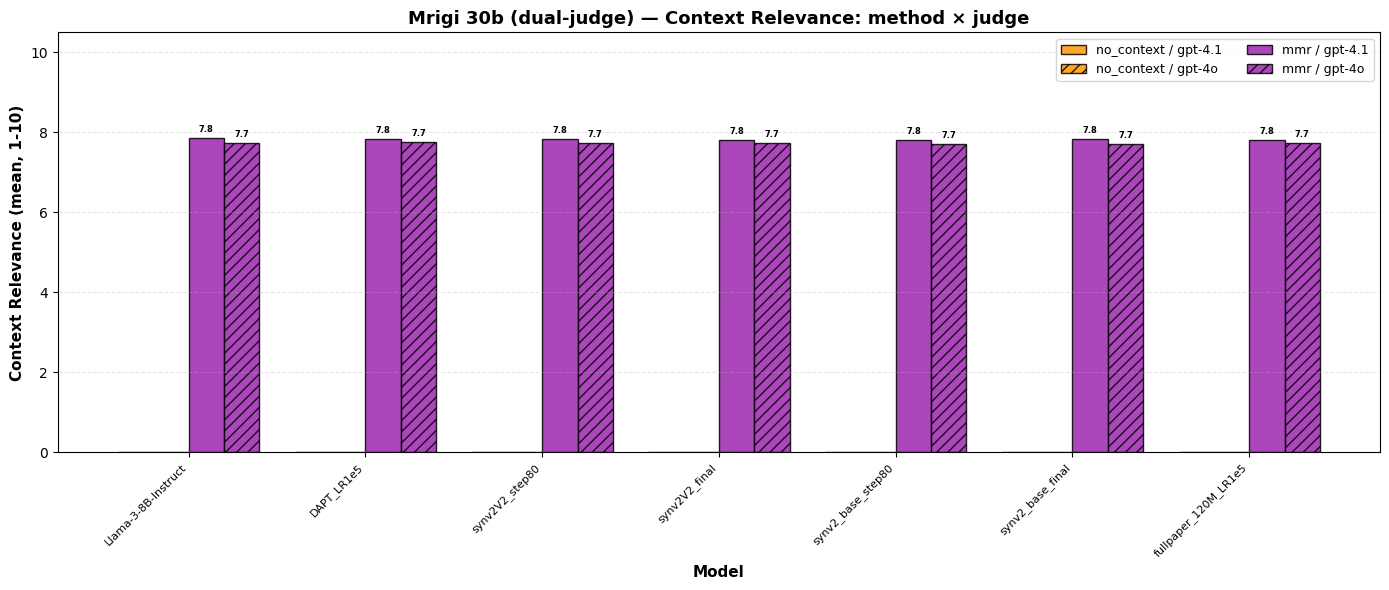

✓ Saved: judge_23j_dual_bars_relevance_mean_20260721_165400.svg


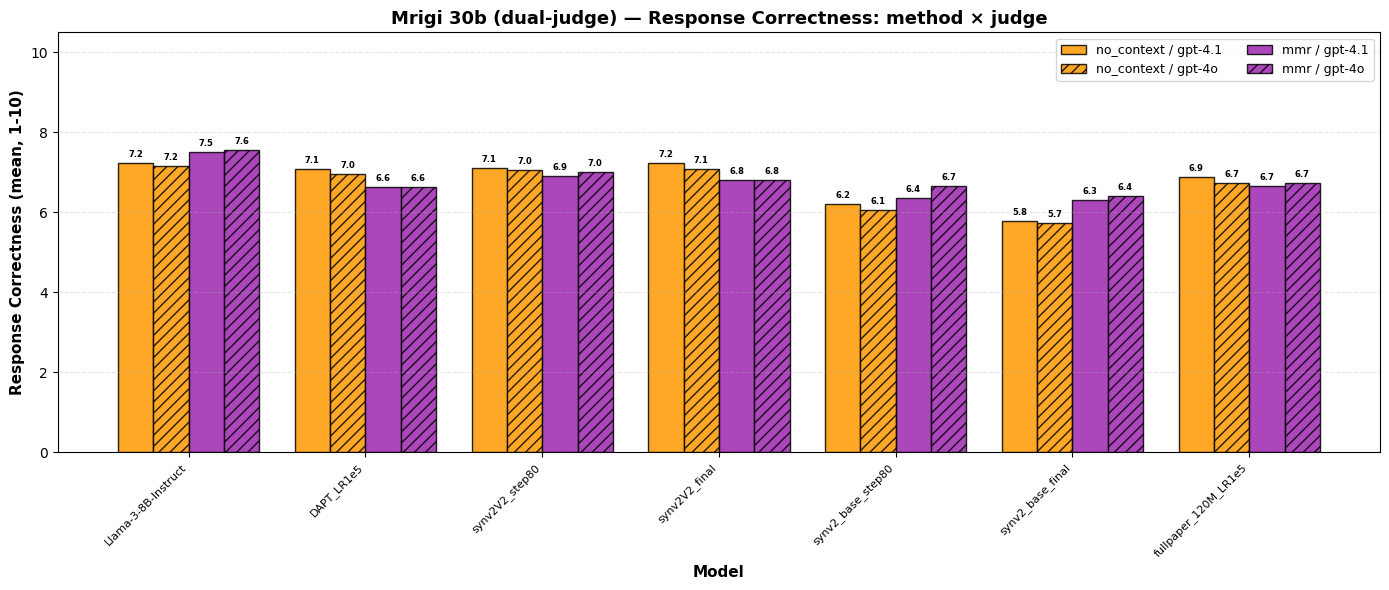

✓ Saved: judge_23j_dual_bars_correctness_mean_20260721_165400.svg


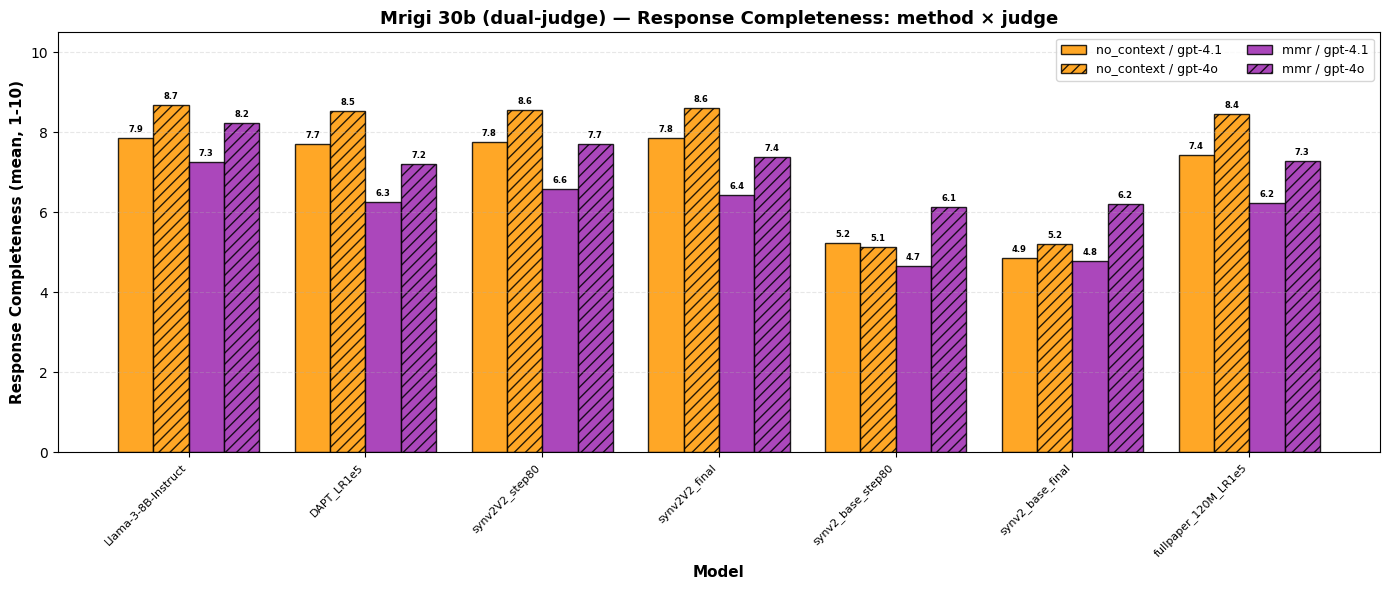

✓ Saved: judge_23j_dual_bars_completeness_mean_20260721_165400.svg


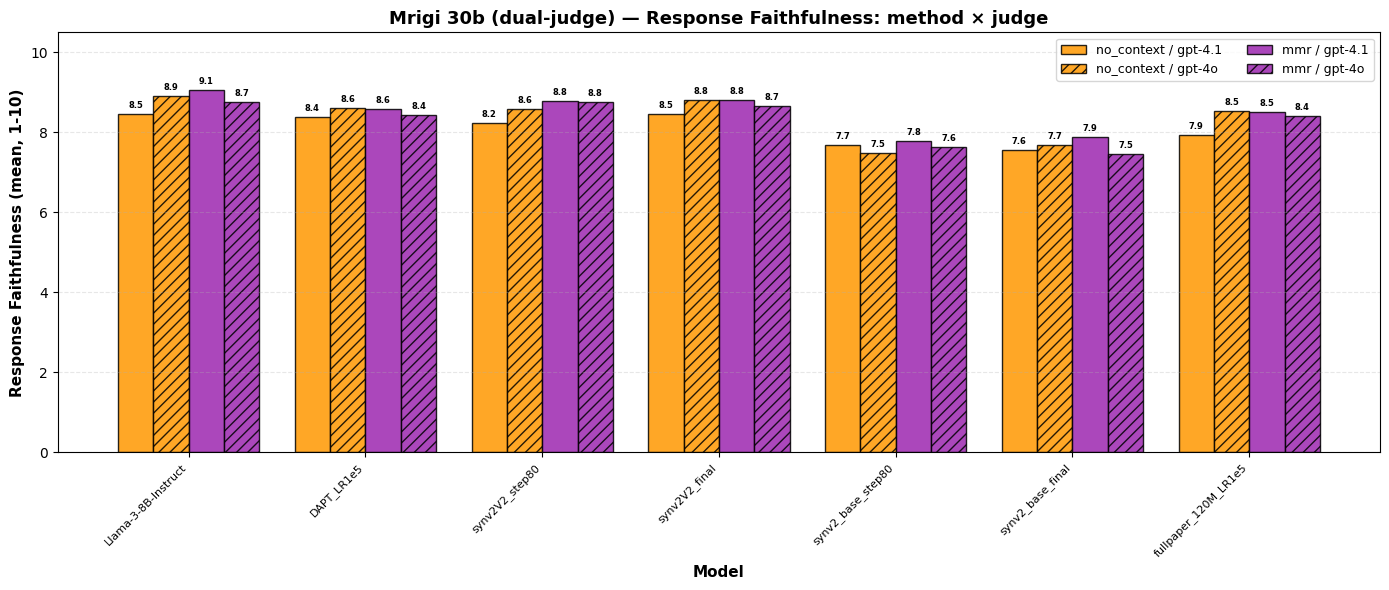

✓ Saved: judge_23j_dual_bars_faithfulness_mean_20260721_165400.svg


In [ ]:
# Plot: per-task bar chart with 4 bars per model = 2 methods × 2 judges.
TASKS = [
    ('relevance_mean',    'Context Relevance'),
    ('correctness_mean',  'Response Correctness'),
    ('completeness_mean', 'Response Completeness'),
    ('faithfulness_mean', 'Response Faithfulness'),
]
# Method colour, judge shading: mmr = darker; gpt-4o gets a hatched pattern to distinguish from gpt-4.1.
METHOD_COLORS = {'no_context': '#FF9800', 'mmr': '#9C27B0'}
JUDGE_HATCH   = {'gpt-4.1': '', 'gpt-4o': '///'}

for task_col, task_title in TASKS:
    fig, ax = plt.subplots(figsize=(max(14, len(MODELS_TO_JUDGE) * 1.4), 6))
    x = np.arange(len(MODELS_TO_JUDGE))
    width = 0.20  # 4 bars per group

    combos = [(m, j) for m in METHODS for j in JUDGE_MODELS]  # 4 combos
    for i, (method, jm) in enumerate(combos):
        sub = (summary_df[(summary_df['method'] == method) & (summary_df['judge'] == jm)]
               .set_index('model').reindex(MODELS_TO_JUDGE))
        vals = sub[task_col].fillna(0).values
        offset = (i - (len(combos) - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width,
                      label=f'{method} / {jm}',
                      color=METHOD_COLORS.get(method), alpha=0.85, edgecolor='black',
                      hatch=JUDGE_HATCH.get(jm, ''))
        for bar, v in zip(bars, vals):
            if not np.isnan(v) and v > 0:
                ax.text(bar.get_x() + bar.get_width()/2., v + 0.1, f'{v:.1f}',
                        ha='center', va='bottom', fontsize=6, fontweight='bold')

    ax.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax.set_ylabel(f'{task_title} (mean, 1-10)', fontsize=11, fontweight='bold')
    ax.set_title(f'Mrigi 30b (dual-judge) — {task_title}: method × judge', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS_TO_JUDGE, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 10.5)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    out = f'judge_23j_dual_bars_{task_col}_{judge_timestamp}.svg'
    fig.savefig(out, format='svg', bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {out}")

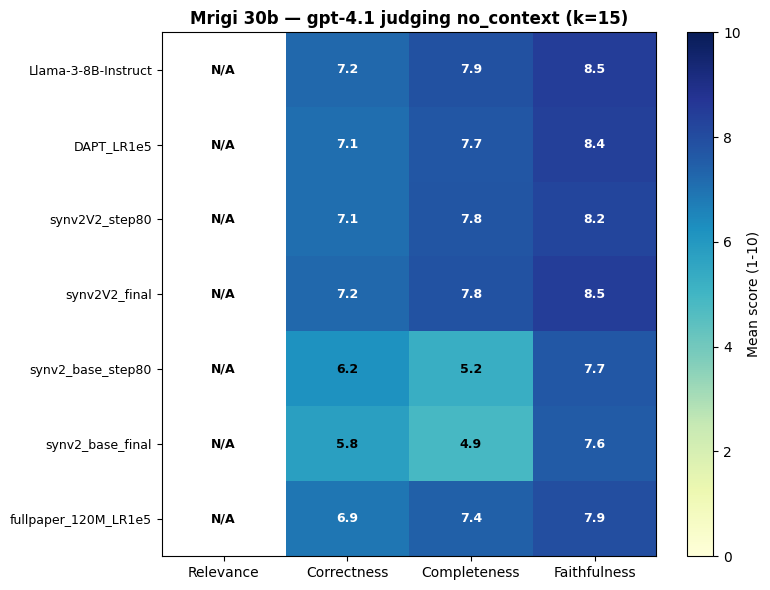

✓ Saved: judge_23j_dual_heatmap_gpt-4.1_no_context_20260721_165400.svg


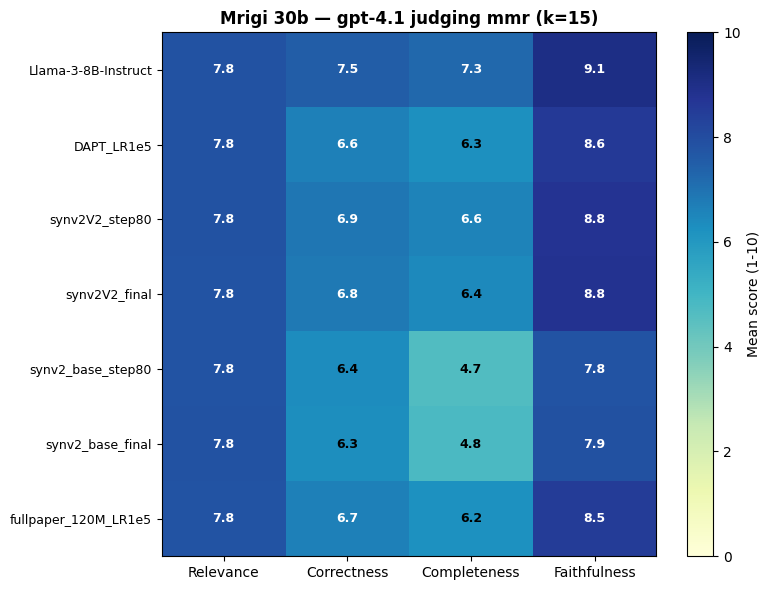

✓ Saved: judge_23j_dual_heatmap_gpt-4.1_mmr_20260721_165400.svg


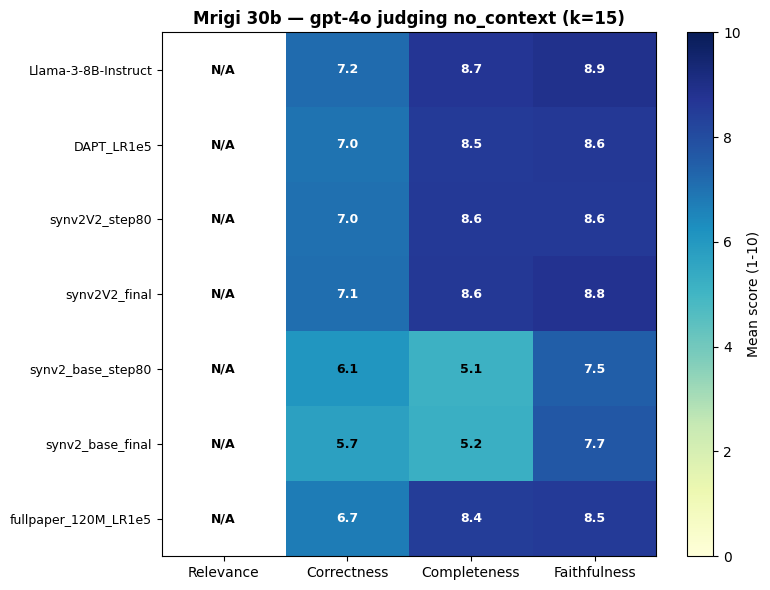

✓ Saved: judge_23j_dual_heatmap_gpt-4o_no_context_20260721_165400.svg


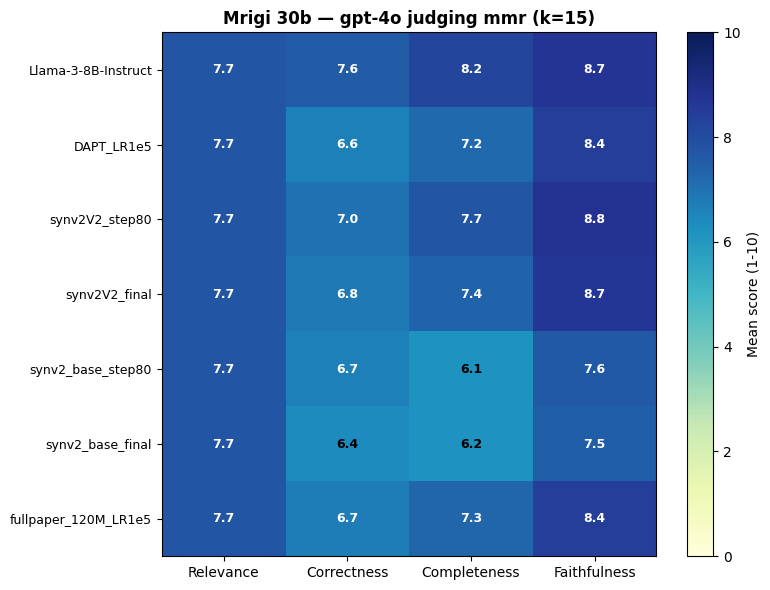

✓ Saved: judge_23j_dual_heatmap_gpt-4o_mmr_20260721_165400.svg


In [ ]:
# Heatmap: models × tasks, one heatmap per (judge, method) → 4 heatmaps.
task_cols   = ['relevance_mean', 'correctness_mean', 'completeness_mean', 'faithfulness_mean']
task_labels = ['Relevance', 'Correctness', 'Completeness', 'Faithfulness']

for jm in JUDGE_MODELS:
    for method in METHODS:
        sub = (summary_df[(summary_df['judge'] == jm) & (summary_df['method'] == method)]
               .set_index('model').reindex(MODELS_TO_JUDGE))
        data = sub[task_cols].values.astype(float)

        fig, ax = plt.subplots(figsize=(8, max(6, len(MODELS_TO_JUDGE) * 0.45)))
        im = ax.imshow(data, aspect='auto', cmap='YlGnBu', vmin=0, vmax=10)

        ax.set_xticks(range(len(task_labels)))
        ax.set_xticklabels(task_labels, fontsize=10)
        ax.set_yticks(range(len(MODELS_TO_JUDGE)))
        ax.set_yticklabels(MODELS_TO_JUDGE, fontsize=9)
        ax.set_title(f'Mrigi 30b — {jm} judging {method} (k=15)', fontsize=12, fontweight='bold')

        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                txt = f'{val:.1f}' if not np.isnan(val) else 'N/A'
                color = 'white' if (not np.isnan(val) and val > 6.5) else 'black'
                ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color, fontweight='bold')

        fig.colorbar(im, ax=ax, label='Mean score (1-10)')
        plt.tight_layout()
        out = f'judge_23j_dual_heatmap_{jm}_{method}_{judge_timestamp}.svg'
        fig.savefig(out, format='svg', bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: {out}")

## Judge Agreement (GPT-4.1 vs GPT-4o)

In [ ]:
# Judge agreement — do gpt-4.1 and gpt-4o give similar scores?
# For each (task, model, method), collect per-question paired scores across judges,
# compute Pearson correlation, mean absolute difference, and % of questions where
# they agree within ±1 point.
from scipy.stats import pearsonr  # scipy is already available in the kernel

agreement_rows = []
for model in MODELS_TO_JUDGE:
    for method in MODEL_METHODS.get(model, METHODS):
        recs = judge_results.get(model, {}).get(method)
        if not recs:
            continue
        for task in TASKS_LIST:
            score_key = f'{task}_score'
            paired = [(r['judges']['gpt-4.1'][score_key], r['judges']['gpt-4o'][score_key])
                      for r in recs
                      if r['judges']['gpt-4.1'][score_key] > 0 and r['judges']['gpt-4o'][score_key] > 0]
            if len(paired) < 3:
                agreement_rows.append({
                    'model': model, 'method': method, 'task': task,
                    'n_paired': len(paired), 'pearson_r': np.nan,
                    'mean_abs_diff': np.nan, 'agree_within_1_pct': np.nan,
                })
                continue
            a = np.array([p[0] for p in paired]); b = np.array([p[1] for p in paired])
            try:
                r_val, _ = pearsonr(a, b)
            except Exception:
                r_val = np.nan
            agreement_rows.append({
                'model': model, 'method': method, 'task': task,
                'n_paired': len(paired),
                'pearson_r': r_val,
                'mean_abs_diff': float(np.mean(np.abs(a - b))),
                'agree_within_1_pct': float(np.mean(np.abs(a - b) <= 1) * 100),
            })

agreement_df = pd.DataFrame(agreement_rows)
agreement_csv = f'judge_agreement_23j_dual_{judge_timestamp}.csv'
agreement_df.to_csv(agreement_csv, index=False)
print(f"✓ Judge-agreement CSV: {agreement_csv}")

# Aggregate view: per-task averages across all models/methods
print("\nJudge-agreement summary (averaged over all models × methods):")
agg = (agreement_df.groupby('task')
       .agg(mean_pearson_r=('pearson_r', 'mean'),
            mean_abs_diff=('mean_abs_diff', 'mean'),
            agree_within_1_pct=('agree_within_1_pct', 'mean'),
            total_paired=('n_paired', 'sum'))
       .round(3))
print(agg.to_string())

✓ Judge-agreement CSV: judge_agreement_23j_dual_20260721_165400.csv

Judge-agreement summary (averaged over all models × methods):
              mean_pearson_r  mean_abs_diff  agree_within_1_pct  total_paired
task                                                                         
completeness           0.737          1.094              76.211          1393
correctness            0.843          0.680              91.807          1393
faithfulness           0.625          1.129              82.142          1393
relevance              0.868          0.418              94.805           693


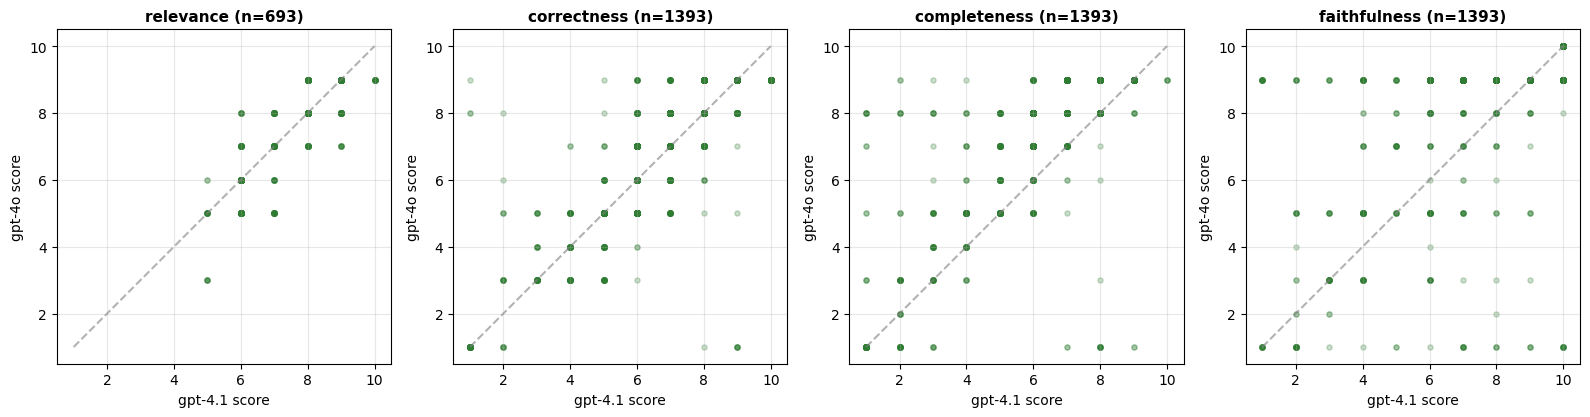

✓ Saved: judge_23j_dual_scatter_20260721_165400.svg


In [ ]:
# Scatter: gpt-4.1 vs gpt-4o per-question scores, one panel per task, pooled across all models+methods.
fig, axes = plt.subplots(1, len(TASKS_LIST), figsize=(4 * len(TASKS_LIST), 4))
for ax, task in zip(axes, TASKS_LIST):
    xs, ys = [], []
    for model in MODELS_TO_JUDGE:
        for method in MODEL_METHODS.get(model, METHODS):
            for r in (judge_results.get(model, {}).get(method) or []):
                a = r['judges']['gpt-4.1'][f'{task}_score']
                b = r['judges']['gpt-4o'][f'{task}_score']
                if a > 0 and b > 0:
                    xs.append(a); ys.append(b)
    ax.scatter(xs, ys, alpha=0.25, s=14, color='#2E7D32')
    ax.plot([1, 10], [1, 10], color='gray', linestyle='--', alpha=0.6)  # y=x reference
    ax.set_xlim(0.5, 10.5); ax.set_ylim(0.5, 10.5)
    ax.set_xlabel('gpt-4.1 score'); ax.set_ylabel('gpt-4o score')
    ax.set_title(f'{task} (n={len(xs)})', fontsize=11, fontweight='bold')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.tight_layout()
out = f'judge_23j_dual_scatter_{judge_timestamp}.svg'
fig.savefig(out, format='svg', bbox_inches='tight')
plt.show()
print(f"✓ Saved: {out}")

In [ ]:
# Final summary printout
print("="*80)
print("Mrigi 30b — Dual-Judge Open-Ended Evaluation Complete")
print("="*80)
print(f"Source file:        {RESULTS_FILE}")
print(f"Final results:      {final_save_path}")
print(f"Summary CSV:        {summary_csv}")
print(f"Agreement CSV:      {agreement_csv}")
print(f"Judges:             {JUDGE_MODELS}")
print(f"Models judged:      {len(MODELS_TO_JUDGE)}")
print(f"Models skipped:     {len(SKIPPED)}")
print(f"Total questions:    {total_evaluated}")
print(f"Elapsed time:       {elapsed/60:.1f} min")
print(f"Worker threads:     {MAX_WORKERS}")
print("="*80)

Mrigi 30b — Dual-Judge Open-Ended Evaluation Complete
Source file:        results_23j_checkpoint.json
Final results:      judge_results_23j_dual_final_20260721_165400.json
Summary CSV:        judge_summary_23j_dual_20260721_165400.csv
Agreement CSV:      judge_agreement_23j_dual_20260721_165400.csv
Judges:             ['gpt-4.1', 'gpt-4o']
Models judged:      7
Models skipped:     7
Total questions:    1400
Elapsed time:       30.0 min
Worker threads:     8
